In [ ]:

"""Problem: Multiple Linear Regression using Gradient Descent

Daataset: Create three feature single target dataset using sklearn.datasets.make_regresion

Task: Apply Gradient Descent on the dataset and find the coefficients theta0, theta1, theta2 and theta3

Use matplotlib to perform data analysis on the dataset and plot scatter of each feature vs target, plot distribution of each feature and target

Normalize the dataset

Apply gradient descent

Calculate the coefficients

Analyze the model on various values of eta

Analyze the model on different size of data

Calculate the coefficients using sklearn library and compare
"""

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


In [30]:

# Generate dataset with 3 features
n_samples = 100
X, y = make_regression(n_samples=n_samples, n_features=3, noise=20, random_state=42)


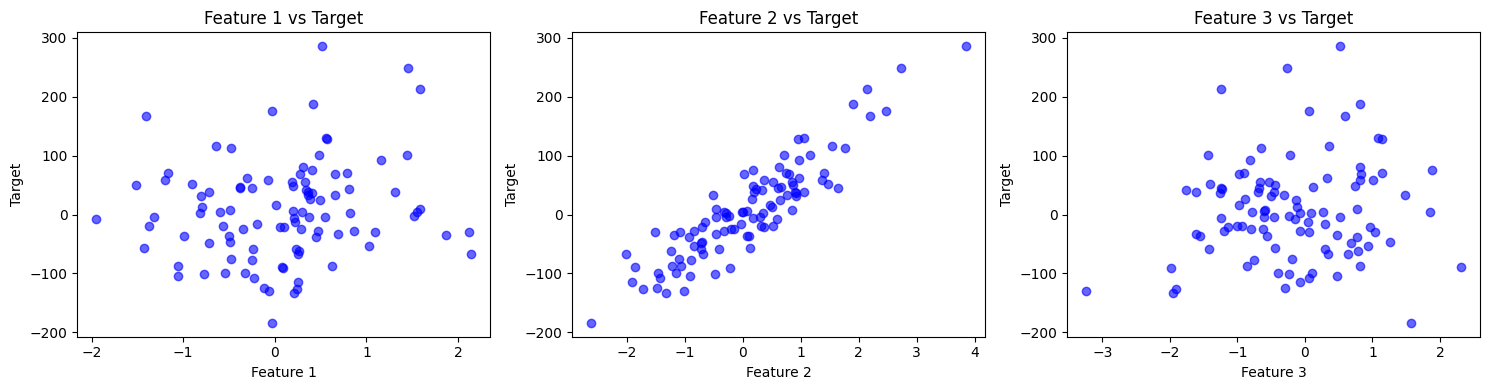

In [31]:
# Scatter plots: Each feature vs Target
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i in range(3):
    axes[i].scatter(X[:, i], y, color='blue', alpha=0.6)
    axes[i].set_xlabel(f'Feature {i+1}')
    axes[i].set_ylabel('Target')
    axes[i].set_title(f'Feature {i+1} vs Target')
plt.tight_layout()
plt.show()

In [32]:
# Normalize the dataset manually (Mean Normalization)
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_scaled = (X - X_mean) / X_std

# Add bias term (column of ones)
X_scaled = np.c_[np.ones(X_scaled.shape[0]), X_scaled]

In [33]:

# Initialize parameters
theta = np.zeros(4)  # 3 features + 1 bias term
learning_rate = 0.1
iterations = 1000

# Gradient Descent Function
def gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    cost_history = []

    for _ in range(iterations):
        prediction = np.dot(X, theta)
        error = prediction - y
        gradient = (1/m) * np.dot(X.T, error)
        theta -= learning_rate * gradient
        cost = (1/(2*m)) * np.sum(error**2)
        cost_history.append(cost)

    return theta, cost_history



In [34]:
# Apply Gradient Descent
theta_final, cost_history = gradient_descent(X_scaled, y, theta.copy(), learning_rate, iterations)

# Print final coefficients
print(f"Gradient Descent Coefficients: theta0 = {theta_final[0]}, theta1 = {theta_final[1]}, theta2 = {theta_final[2]}, theta3 = {theta_final[3]}")

# Compute MSE for Gradient Descent
mse_gd = mean_squared_error(y, np.dot(X_scaled, theta_final))
print(f"MSE (Gradient Descent): {mse_gd}")

# Compare with sklearn's Linear Regression
lr = LinearRegression()
lr.fit(X_scaled[:, 1:], y)  # Exclude bias column for sklearn
theta_sklearn = np.append(lr.intercept_, lr.coef_)

# Print sklearn coefficients
print(f"Sklearn Coefficients: theta0 = {theta_sklearn[0]}, theta1 = {theta_sklearn[1]}, theta2 = {theta_sklearn[2]}, theta3 = {theta_sklearn[3]}")

# Compute MSE for Sklearn
mse_sklearn = mean_squared_error(y, lr.predict(X_scaled[:, 1:]))
print(f"MSE (Sklearn): {mse_sklearn}")


Gradient Descent Coefficients: theta0 = 6.9259400676475815, theta1 = 23.332306382122983, theta2 = 80.74835229837412, theta3 = 19.34033394779082
MSE (Gradient Descent): 395.29924031060136
Sklearn Coefficients: theta0 = 6.925940067647584, theta1 = 23.33230638212301, theta2 = 80.74835229837421, theta3 = 19.340333947790842
MSE (Sklearn): 395.29924031060136


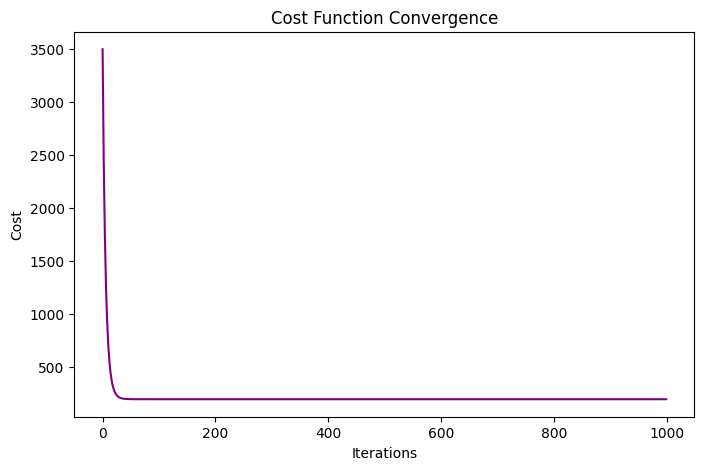

In [35]:

# Plot Cost Function Convergence
plt.figure(figsize=(8, 5))
plt.plot(range(iterations), cost_history, color='purple')
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Function Convergence")
plt.show()
